In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,accuracy_score

# --- BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP ---
np.random.seed(42)
people = 100

tuoi = np.random.randint(18,70, people)
luong = np.random.randint(2000, 20000, people)

xac_suat = (tuoi * 0.05) + (luong *0.001) + np.random.normal(0, 1, people)
mua_xe = (xac_suat > 13).astype(int)

df_ads = pd.DataFrame({
    "Tuổi": tuoi,
    "Lương ($)": luong,
    "Xác suất mua xe": xac_suat,
    "Mua xe": mua_xe
})

print(df_ads.head())

# --- BƯỚC 2: HUẤN LUYỆN AI ---
X = df_ads[["Tuổi", "Lương ($)"]]
y = df_ads["Mua xe"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# --- BƯỚC 3: KIỂM TRA ---
y_pred = model.predict(X_test)

kqt = pd.DataFrame({
    "Tuổi": X_test["Tuổi"],
    "Lương ($)": X_test["Lương ($)"],
    "Tỉ lệ thực tế": y_test.values.flatten(),
    "Tỉ lệ AI dự đoán": y_pred.flatten()
})

print(kqt.head())
print(f"Độ chính xác của AI: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Trọng số AI tìm được (w1, w2):", model.coef_)
print("Con số AI tự trừ đi (b - Intercept):", model.intercept_)

   Tuổi  Lương ($)  Xác suất mua xe  Mua xe
0    56      18448        19.697337       1
1    69      18216        21.734563       1
2    46      10006        11.243696       0
3    32       4568         6.641592       0
4    60       4027         6.107576       0
    Tuổi  Lương ($)  Tỉ lệ thực tế  Tỉ lệ AI dự đoán
83    32       6931              0                 0
53    43      12173              1                 1
70    23       8585              0                 0
45    26      12921              1                 1
44    38      12817              1                 1
Độ chính xác của AI: 95.00%
Trọng số AI tìm được (w1, w2): [[0.05066742 0.00136424]]
Con số AI tự trừ đi (b - Intercept): [-16.94783824]


In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings

settings = {"hidden_layer_sizes": (8, 4), "max_iter": 10000, "random_state": 42}

print("NGÀY 57: MẠNG NƠ-RON NHÂN TẠO (NEURAL NETWORKS) - BỘ NÃO CỦA MÁY TÍNH")

# Tắt các cảnh báo lặt vặt cho màn hình console sạch sẽ
warnings.filterwarnings("ignore")

# 1. BẮT BUỘC: Mạng nơ-ron rất nhạy cảm với độ lớn của dữ liệu, nên chúng ta cần chuẩn hóa dữ liệu trước khi huấn luyện.
scaler = StandardScaler() #Chuẩn hóa dữ liệu
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Khởi tạo bộ não 
#hidden_layer_sizes=(8, 4) tạo ra 2 lớp ẩn
# max_iter = 1000 cho phép máy suy nghĩ 1000 vòng
brain_ai = MLPClassifier(activation="relu", **settings)

# 3. Quá trình học (y hệt Machine Learning truyền thống)
brain_ai.fit(X_train_scaled, y_train)

# 4. Kiểm tra độ thông minh của bộ não
y_pred_nn = brain_ai.predict(X_test_scaled)
acc_nn = accuracy_score(y_test, y_pred_nn)

print(f"Độ chính xác của mạng nơ-ron là: {acc_nn * 100:.2f}%")




NGÀY 57: MẠNG NƠ-RON NHÂN TẠO (NEURAL NETWORKS) - BỘ NÃO CỦA MÁY TÍNH
Độ chính xác của mạng nơ-ron là: 95.00%


In [13]:
print("\n--- NGÀY 58: THỬ NGHIỆM CÁC HÀM KÍCH HOẠT (ACTIVATION FUNCTIONS) ---")

# 1. Bộ não dùng Tanh (bóp dữ liệu từ -1 đến 1)
brain_tanh = MLPClassifier(activation='tanh', **settings)
brain_tanh.fit(X_train_scaled,y_train)
y_pred_tanh = brain_tanh.predict(X_test_scaled)
acc_tanh = accuracy_score(y_test,y_pred_tanh)

# 2. Bộ não dùng Logistic / Sigmoid (bóp dữ liệu từ 0 đến 1)
brain_sigmoid = MLPClassifier(activation='logistic', **settings)
brain_sigmoid.fit(X_train_scaled,y_train)
y_pred_sigmoid = brain_sigmoid.predict(X_test_scaled)
acc_sigmoid = accuracy_score(y_test,y_pred_sigmoid)

print(f"Độ chính xác của mạng nơ-ron với hàm ReLU (mặc định): {acc_nn * 100:.2f}%")
print(f"Độ chính xác của mạng nơ-ron với hàm Tanh: {acc_tanh * 100:.2f}%")
print(f"Độ chính xác của mạng nơ-ron với hàm Sigmoid: {acc_sigmoid * 100:.2f}%")




--- NGÀY 58: THỬ NGHIỆM CÁC HÀM KÍCH HOẠT (ACTIVATION FUNCTIONS) ---
Độ chính xác của mạng nơ-ron với hàm ReLU (mặc định): 95.00%
Độ chính xác của mạng nơ-ron với hàm Tanh: 95.00%
Độ chính xác của mạng nơ-ron với hàm Sigmoid: 95.00%


In [14]:
# print("\n--- CUỘC ĐUA TỐC ĐỘ: CHỈ VỚI 50 VÒNG LẶP ---")

# # Thử nghiệm với max_iter rất nhỏ
# settings = {"hidden_layer_sizes": (8, 4), "max_iter": 50, "random_state": 42}

# # 1. ReLU
# brain_relu_fast = MLPClassifier(activation='relu', **settings).fit(X_train_scaled, y_train)
# # 2. Tanh
# brain_tanh_fast = MLPClassifier(activation='tanh', **settings).fit(X_train_scaled, y_train)
# # 3. Sigmoid
# brain_sigmoid_fast = MLPClassifier(activation='logistic', **settings).fit(X_train_scaled, y_train)

# print(f"ReLU (50 vòng): {accuracy_score(y_test, brain_relu_fast.predict(X_test_scaled)) * 100:.2f}%")
# print(f"Tanh (50 vòng): {accuracy_score(y_test, brain_tanh_fast.predict(X_test_scaled)) * 100:.2f}%")
# print(f"Sigmoid (50 vòng): {accuracy_score(y_test, brain_sigmoid_fast.predict(X_test_scaled)) * 100:.2f}%")


--- NGÀY 59: THEO DÕI QUÁ TRÌNH HỌC (LOSS CURVE) ---
AI đã tự dừng lại ở bước (vòng lặp) thứ: 1669


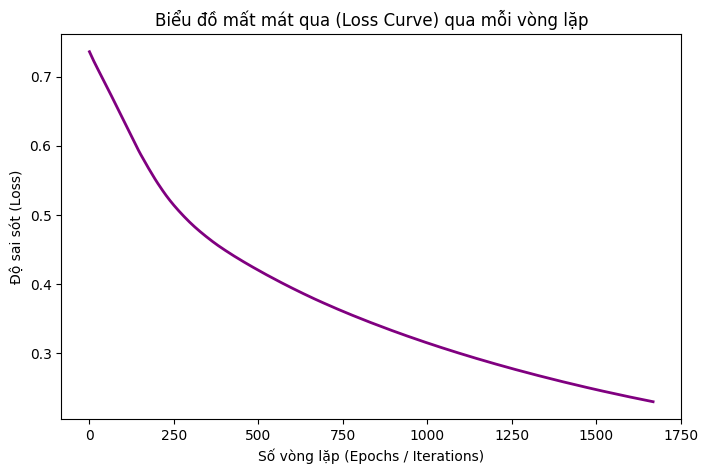

In [15]:
import matplotlib.pyplot as plt

print("\n--- NGÀY 59: THEO DÕI QUÁ TRÌNH HỌC (LOSS CURVE) ---")

# 1. Lấy lịch sử sửa sai của mô hình (mỗi con số là độ lỗi của 1 vòng lặp)
lich_su_hoc = brain_ai.loss_curve_

print(f"AI đã tự dừng lại ở bước (vòng lặp) thứ: {len(lich_su_hoc)}")

# 2. Vẽ biểu đồ quá trình học
plt.figure(figsize=(8,5))
plt.plot(lich_su_hoc, color='purple', linewidth=2)

#trang trí biểu đồ
plt.title("Biểu đồ mất mát qua (Loss Curve) qua mỗi vòng lặp")
plt.xlabel("Số vòng lặp (Epochs / Iterations)")
plt.ylabel("Độ sai sót (Loss)")

plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print("\n--- NGÀY 60: CHÀO MỪNG ĐẾN VỚI TENSORFLOW & KERAS ---")

# 1.Khởi tạo mô hình dạng chuỗi (Sequential - từng lớp xếp chồng lên nhau)
model_tf = Sequential()

# 2. Lắp rắp các lớp nơ-ron vào mô hình
# lớp ẩn 1: 8 nơ-ron, nhận vào 2 cột (Tuổi, Lương ($))
model_tf.add(Input(batch_shape=(None, 2)))
model_tf.add(Dense(8, activation='relu'))

# Lớp ẩn 2: 4 nơ-ron
model_tf.add(Dense(4, activation='relu'))

# Lớp đầu ra: 1 nơ-ron (dự đoán 0 hoặc 1) dùng sigmoid
model_tf.add(Dense(1, activation='sigmoid'))
# optimizer='adam' là phiên bản nâng cấp cực xịn, thông minh hơn Gradient Descent thường
# loss='binary_crossentropy' là thước đo chuẩn xác nhất cho bài toán Phân loại 2 nhóm
model_tf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. In bản thiết kế của mô hình ra màn hình
print("Bản thiết kế mô hình TensorFlow/Keras:")
model_tf.summary()

# 5. Huấn luyện mô hình
print("\nBắt đầu huấn luyện với TensorFlow... (Chạy 100 vòng)")
# epochs=100 nghĩa là ép AI cày nát toàn bộ tập dữ liệu 100 lần (tương đương iter)
lich_su_hoc_tf = model_tf.fit(X_train_scaled, y_train, epochs=100, verbose=1)

print("Huấn luyện xong!")

# 6.Lấy điểm cuối cùng
acc_list = lich_su_hoc_tf.history['accuracy']
final_score = acc_list[-1]  # Điểm cuối cùng sau 100 vòng lặp   
print(f"Độ chính xác trên tập Train (ở vòng lặp thứ 100): {final_score * 100:.2f}%")

# Bonus: Xem tổn thất (Loss) có thấp không
final_loss = lich_su_hoc_tf.history['loss'][-1]
print(f"Độ sai sót (Loss) còn lại: {final_loss:.4f}")

print(lich_su_hoc_tf.history.keys())



--- NGÀY 60: CHÀO MỪNG ĐẾN VỚI TENSORFLOW & KERAS ---
Bản thiết kế mô hình TensorFlow/Keras:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện với TensorFlow... (Chạy 100 vòng)
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7750 - loss: 0.6111
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7375 - loss: 0.6054
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7375 - loss: 0.5998
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7375 - loss: 0.5944
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7750 - loss: 0.5888
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7750 - loss: 0.5834 
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7750 - loss: 0.5780
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7750 - loss: 0.5724
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7875 - loss: 0.5674
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8000 - loss: 0.5618
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8000 - loss: 0.5569
Epoch 12/100
3/3 ━━

dict_keys(['accuracy', 'loss'])
